# Day 6

Goals: 
1. Implement uniform cost search and A* (A star) by Sep 14.
2. Benchmark bfs, dfs, ucs, astar for 2 given search problems.

   From course repo: copy `lab/search_problems.pyc` to your lab folder.

In [1]:
# make sure search_problems.pyc (updated 9/11, 5:00pm) exists in the current folder
# this imports search problem classes and a set of specific problems.
from search_problems import *
# we will also use numpy a bit
import numpy as np

## Weighted Mazes
Here I will show you how to use the functions in `WeightedMazeProblems`

In [2]:
problem = WeightedMazeProblem(WEIGHTED_MAZES[0])
# There are many more problems: up to 1000. For example, try
# problem = WeightedMazeProblem(WEIGHTED_MAZES[999])

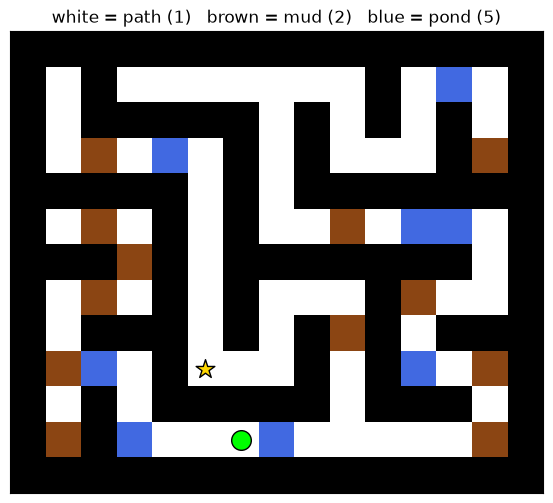

In [3]:
# Here's how to plot the problem
problem.plot_problem()

Below is some example code for you to understand the syntax of the classes. It should work like what we were looking at in class.

In [4]:
print('Initial state:', problem.start)
neighbors = problem.neighbors(problem.start)
print('Neighbors:', neighbors)
print('Cost to go from start to a neighbor:', problem.step_cost(problem.start, neighbors[0]))
print('Check if neighbor is a goal:', problem.goal_test(neighbors[0]))

Initial state: (11, 6)
Neighbors: [(11, 5), (11, 7)]
Cost to go from start to a neighbor: 1
Check if neighbor is a goal: False


In [5]:
# You can directly check the goal state as follows, 
# but remember that uninformed search doesn't have access to this.
print(problem.goal)

(9, 5)


In [6]:
# Maze problems use Manhattan distance, which we will use in A star.
print('Manhattan distance from start to goal is:', problem.heuristic(problem.start))

Manhattan distance from start to goal is: 3


bfs, dfs, and reconstruct_path are included in the package (just like in maze2.py). Let's run dfs on this problem.

In [7]:
state, path, expanded = dfs(problem)

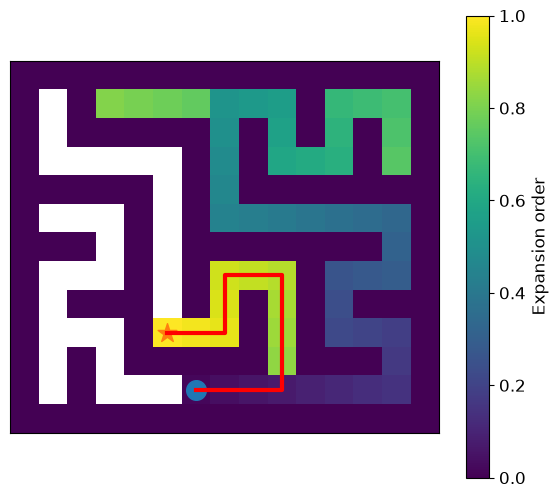

In [8]:
# plot the solution using the built-in function
problem.plot_search(expanded, path)

(Notice that dfs doesn't care about going through costly states!)

In [9]:
# How many nodes did we have to check?
# remember that expanded is a list of all expanded nodes.
print(len(expanded), 'nodes searched.')

54 nodes searched.


Let's try 1000 running dfs over 1000 weighted maze problems...

In [10]:
search_steps = []
failures = 0
for i in range(1000):
    problem = WeightedMazeProblem(WEIGHTED_MAZES[i])
    state, path, expanded = dfs(problem)
    if state:
        search_steps.append(len(expanded))
    else:
        failures += 1

In [11]:
print(failures, 'failures.')
print('average number of steps was', np.mean(search_steps))
print('the fastest search had', np.min(search_steps), 'steps.')
print('the longest search had', np.max(search_steps), 'steps.')


0 failures.
average number of steps was 30.643
the fastest search had 2 steps.
the longest search had 91 steps.


Next: Work on ucs below, or paste it if you already have it. After ucs, implement a_star.

Do a comparison of bfs, dfs, ucs, and a_star.

If you have time: implement greedy and add it to the comparison.

## Eight Puzzle

Different problem, but your search algorithms should interface with it the same.

In [12]:
problem = EightPuzzleProblem(EIGHT_PUZZLE_STATES[999], heuristic_name = 'misplaced')

In [13]:
problem.plot_problem()

Initial state:
| 8 | 7 | 3 |
| 5 | 1 | 6 |
| 2 |   | 4 |


In [14]:
problem.start

'873516204'

In [15]:
# GOAL is a parameter because the goal state is the same for every problem.
problem.GOAL

'123456780'

Everything should work the same as the maze. One wrinkle, though. What would be a good heuristic function? I've included two possibilities. One is called `misplaced`: Noticed that we set `heuristic_name` when creating the `problem` object. This counts the number of blocks in the puzzle that are not in the correct position. So the heuristic can be as high as 8 and the goal is to make it 0.

In [16]:
problem.heuristic(problem.start)

6

Another heuristic would be to add up the Manhattan distance between the position of each number and where it should be in the goal state. use `heuristic = 'manhattan'` (or don't define it. heuristic is set to manhattan by default.)

In [17]:
problem = EightPuzzleProblem(EIGHT_PUZZLE_STATES[999])

In [18]:
problem.heuristic(problem.start)

15

You should now be able to run your search algorithms on the Eight Puzzle problem. For A*: use both heuristics in the comparison. Let me know if you have any questions!